<a href="https://colab.research.google.com/github/Semere-Mesfin-Gebresilassie/Semere-Mesfin-Gebresilassie/blob/main/Student_and_Alumni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Students & Alumni Survey Data Analysis
# BSc Civil Engineering Curriculum Review

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
# Read the Excel file
file_path = '/content/Student or Alumini(Edited).xlsx'
df = pd.read_excel(file_path)

In [ ]:
# Apply column renaming based on our recommended names
column_mapping = {
    'Please select The Stockholder of the Target Interview': 'Respondent_Type',
    '1. Status:': 'Status',
    '2. Year of graduation': 'Grad_Year',
    '3. Current status:': 'Current_Status',
    'a. Quality of teaching': 'Rating_Teaching_Quality',
    'b. Practical / laboratory exposure': 'Rating_Practical_Lab',
    'c. Fieldwork and site visits': 'Rating_Fieldwork',
    'd. Software training': 'Rating_Software_Training',
    'e. Final-year project relevance': 'Rating_FYP_Relevance',
    'Employability': 'Agree_Curriculum_Prepared',
    '5.      The\ncurriculum prepared me for employment:': 'Curriculum_Preparedness',
    '6. Most useful courses for your career:': 'Useful_Courses',
    '7. Least useful courses:': 'Least_Useful_Courses',
    '8. Should practical components be increased?': 'Increase_Practical',
    '9. Areas where you faced difficulty after graduation (tick all that apply):/Design': 'Diff_Design',
    '9. Areas where you faced difficulty after graduation (tick all that apply):/Software': 'Diff_Software',
    '9. Areas where you faced difficulty after graduation (tick all that apply):/Site Management': 'Diff_Site_Mgmt',
    '9. Areas where you faced difficulty after graduation (tick all that apply):/Communication': 'Diff_Communication',
    '9. Areas where you faced difficulty after graduation (tick all that apply):/Reporting & Documentation': 'Diff_Reporting',
    '10. Suggestions to improve the curriculum:': 'Curriculum_Suggestions',
    'Basic programming': 'Exp_Basic_Programming',
    'Data analysis tools': 'Exp_Data_Analysis',
    'GIS applications': 'Exp_GIS',
    'Any AI/ML discussion': 'Exp_AI_ML',
    '12. How important are digital skills in your current work/future career?': 'Digital_Skills_Importance',
    '13. Which digital skills do you wish you had learned? (Select top 3)/Programming (Python, MATLAB)': 'Wish_Programming',
    '13. Which digital skills do you wish you had learned? (Select top 3)/Data analysis/Excel advanced': 'Wish_Data_Analysis',
    '13. Which digital skills do you wish you had learned? (Select top 3)/GIS and remote sensing': 'Wish_GIS',
    '13. Which digital skills do you wish you had learned? (Select top 3)/Project management software': 'Wish_Project_Mgmt',
    '13. Which digital skills do you wish you had learned? (Select top 3)/AI/ML basics': 'Wish_AI_ML',
    '13. Which digital skills do you wish you had learned? (Select top 3)/Other': 'Wish_Other',
    '14. Would you take elective courses in emerging technologies?': 'Take_Elective_Courses',
    '15. Should Adigrat University pioneer digital skills integration in Ethiopian civil engineering?': 'Pioneer_Digital_Skills'
}

# Rename columns (only those that exist in the dataframe)
df.rename(columns={k: v for k, v in column_mapping.items() if k in df.columns}, inplace=True)

# Data Cleaning and Preparation
# Convert rating columns to numeric
rating_cols = ['Rating_Teaching_Quality', 'Rating_Practical_Lab', 'Rating_Fieldwork',
               'Rating_Software_Training', 'Rating_FYP_Relevance', 'Curriculum_Preparedness']

for col in rating_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert binary columns (Yes/No, 1/0) to numeric
binary_cols = ['Exp_Basic_Programming', 'Exp_Data_Analysis', 'Exp_GIS', 'Exp_AI_ML',
               'Diff_Design', 'Diff_Software', 'Diff_Site_Mgmt', 'Diff_Communication', 'Diff_Reporting']

for col in binary_cols:
    if col in df.columns:
        # Convert 'Yes' to 1, 'No' to 0, and handle numeric values
        df[col] = df[col].map({'Yes': 1, 'No': 0, 'Not Sure': 0}).fillna(df[col])
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Convert wish skills to binary
wish_cols = ['Wish_Programming', 'Wish_Data_Analysis', 'Wish_GIS', 'Wish_Project_Mgmt', 'Wish_AI_ML', 'Wish_Other']
for col in wish_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Create a clean copy for analysis
df_clean = df.copy()

print("="*80)
print("CIVIL ENGINEERING CURRICULUM SURVEY ANALYSIS")
print("="*80)
print(f"\nTotal Respondents: {len(df_clean)}")
print(f"Final-Year Students: {len(df_clean[df_clean['Status'] == 'Final-Year Student'])}")
print(f"Alumni: {len(df_clean[df_clean['Status'] == 'Alumni'])}")

# Filter out non-numeric rows for analysis
df_analysis = df_clean[df_clean['Status'].isin(['Final-Year Student', 'Alumni'])].copy()

CIVIL ENGINEERING CURRICULUM SURVEY ANALYSIS

Total Respondents: 41
Final-Year Students: 18
Alumni: 23


In [ ]:
# 1. SUMMARY STATISTICS FOR RATINGS
print("\n" + "="*80)
print("1. CURRICULUM RATINGS SUMMARY")
print("="*80)

# Filter rating_cols to only include columns present in df_analysis
actual_rating_cols = [col for col in rating_cols if col in df_analysis.columns]

rating_summary = df_analysis[actual_rating_cols].describe()
print(rating_summary)

# 2. COMPARISON BETWEEN STUDENTS AND ALUMNI
print("\n" + "="*80)
print("2. COMPARISON: FINAL-YEAR STUDENTS VS ALUMNI")
print("="*80)

comparison = df_analysis.groupby('Status')[actual_rating_cols].mean()
print(comparison)


1. CURRICULUM RATINGS SUMMARY
       Rating_Teaching_Quality  Rating_Practical_Lab  Rating_Fieldwork
count                41.000000             41.000000         41.000000
mean                  3.780488              2.536585          2.804878
std                   1.107073              1.361939          1.327018
min                   1.000000              1.000000          1.000000
25%                   3.000000              1.000000          2.000000
50%                   4.000000              2.000000          3.000000
75%                   5.000000              3.000000          4.000000
max                   5.000000              5.000000          5.000000

2. COMPARISON: FINAL-YEAR STUDENTS VS ALUMNI
                    Rating_Teaching_Quality  Rating_Practical_Lab  \
Status                                                              
Alumni                             3.521739              2.260870   
Final-Year Student                 4.111111              2.888889   

       

In [ ]:
# 3. DIGITAL SKILLS EXPOSURE ANALYSIS
print("\n" + "="*80)
print("3. DIGITAL SKILLS EXPOSURE DURING STUDIES")
print("="*80)

exposure_summary = df_analysis[['Exp_Basic_Programming', 'Exp_Data_Analysis', 'Exp_GIS', 'Exp_AI_ML']].mean() * 100
print(exposure_summary.sort_values(ascending=False))


3. DIGITAL SKILLS EXPOSURE DURING STUDIES
Exp_Data_Analysis        53.658537
Exp_Basic_Programming    51.219512
Exp_GIS                  41.463415
Exp_AI_ML                34.146341
dtype: float64


In [ ]:
# 4. DESIRED DIGITAL SKILLS (What students wish they learned)
print("\n" + "="*80)
print("4. TOP DIGITAL SKILLS STUDENTS WISH THEY HAD LEARNED")
print("="*80)

wish_summary = df_analysis[wish_cols].sum().sort_values(ascending=False)
print(wish_summary)


4. TOP DIGITAL SKILLS STUDENTS WISH THEY HAD LEARNED
Wish_Project_Mgmt     29
Wish_Data_Analysis    22
Wish_Programming      14
Wish_GIS              14
Wish_Other            12
Wish_AI_ML             8
dtype: int64


In [ ]:
# 5. DIFFICULTY AREAS AFTER GRADUATION
print("\n" + "="*80)
print("5. DIFFICULTY AREAS FACED AFTER GRADUATION")
print("="*80)

difficulty_cols = ['Diff_Design', 'Diff_Software', 'Diff_Site_Mgmt', 'Diff_Communication', 'Diff_Reporting']
difficulty_summary = df_analysis[difficulty_cols].mean() * 100
print(difficulty_summary.sort_values(ascending=False))


5. DIFFICULTY AREAS FACED AFTER GRADUATION
Diff_Software         80.487805
Diff_Design           53.658537
Diff_Site_Mgmt        39.024390
Diff_Reporting        29.268293
Diff_Communication    17.073171
dtype: float64


In [ ]:
# 6. PRACTICAL COMPONENTS OPINION
print("\n" + "="*80)
print("6. OPINION ON INCREASING PRACTICAL COMPONENTS")
print("="*80)

practical_counts = df_analysis['Increase_Practical'].value_counts()
print(practical_counts)


6. OPINION ON INCREASING PRACTICAL COMPONENTS
Increase_Practical
Yes    38
No      3
Name: count, dtype: int64


In [ ]:
# 7. DIGITAL SKILLS IMPORTANCE
print("\n" + "="*80)
print("7. PERCEIVED IMPORTANCE OF DIGITAL SKILLS")
print("="*80)

importance_counts = df_analysis['Digital_Skills_Importance'].value_counts()
print(importance_counts)


7. PERCEIVED IMPORTANCE OF DIGITAL SKILLS
Digital_Skills_Importance
Essential               29
Very important          11
Moderately important     1
Name: count, dtype: int64


In [ ]:
# 8. WILLINGNESS TO TAKE ELECTIVE COURSES
print("\n" + "="*80)
print("8. INTEREST IN ELECTIVE COURSES IN EMERGING TECHNOLOGIES")
print("="*80)

elective_counts = df_analysis['Take_Elective_Courses'].value_counts()
print(elective_counts)



8. INTEREST IN ELECTIVE COURSES IN EMERGING TECHNOLOGIES
Take_Elective_Courses
Yes, if relevant to career    20
Yes, definitely               18
Maybe                          2
Definitely not                 1
Name: count, dtype: int64


In [ ]:
# 9. PIONEER DIGITAL SKILLS INTEGRATION
print("\n" + "="*80)
print("9. OPINION ON ADIGRAT UNIVERSITY PIONEERING DIGITAL SKILLS")
print("="*80)

pioneer_counts = df_analysis['Pioneer_Digital_Skills'].value_counts()
print(pioneer_counts)


9. OPINION ON ADIGRAT UNIVERSITY PIONEERING DIGITAL SKILLS
Pioneer_Digital_Skills
Yes, be a leader               21
Yes, but cautiously            11
No, focus on basics             5
Wait for other universities     2
No opinion                      2
Name: count, dtype: int64


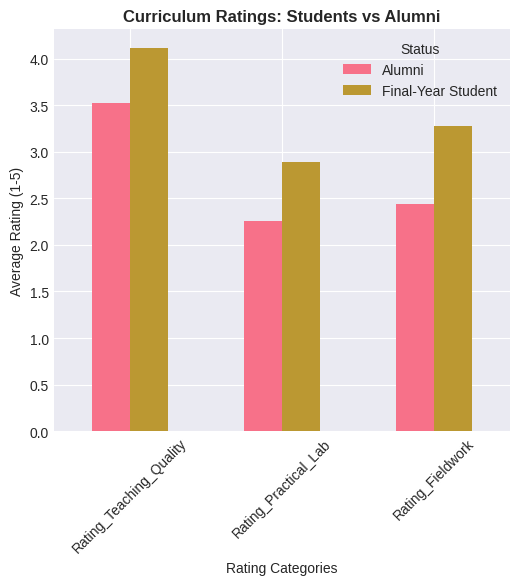

In [ ]:
# VISUALIZATIONS
fig = plt.figure(figsize=(20, 24))

# 1. Rating Comparison Bar Chart
ax1 = plt.subplot(4, 3, 1)
# Use actual_rating_cols which contains only the existing rating columns
rating_comparison = df_analysis.groupby('Status')[actual_rating_cols].mean()
rating_comparison.T.plot(kind='bar', ax=ax1)
ax1.set_title('Curriculum Ratings: Students vs Alumni', fontsize=12, fontweight='bold')
ax1.set_xlabel('Rating Categories')
ax1.set_ylabel('Average Rating (1-5)')
ax1.legend(title='Status')
ax1.tick_params(axis='x', rotation=45)

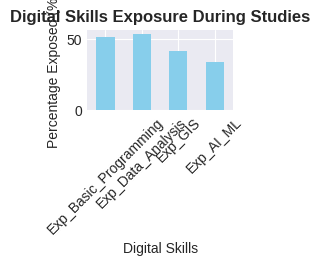

In [ ]:
# 2. Digital Skills Exposure
ax2 = plt.subplot(4, 3, 2)
exposure_data = df_analysis[['Exp_Basic_Programming', 'Exp_Data_Analysis', 'Exp_GIS', 'Exp_AI_ML']].mean() * 100
exposure_data.plot(kind='bar', ax=ax2, color='skyblue')
ax2.set_title('Digital Skills Exposure During Studies', fontsize=12, fontweight='bold')
ax2.set_xlabel('Digital Skills')
ax2.set_ylabel('Percentage Exposed (%)')
ax2.tick_params(axis='x', rotation=45)

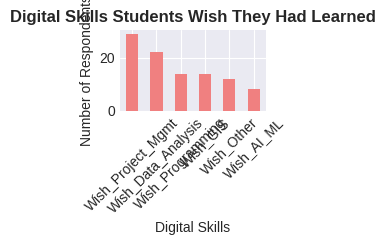

In [ ]:
# 3. Desired Digital Skills
ax3 = plt.subplot(4, 3, 3)
wish_summary.plot(kind='bar', ax=ax3, color='lightcoral')
ax3.set_title('Digital Skills Students Wish They Had Learned', fontsize=12, fontweight='bold')
ax3.set_xlabel('Digital Skills')
ax3.set_ylabel('Number of Respondents')
ax3.tick_params(axis='x', rotation=45)

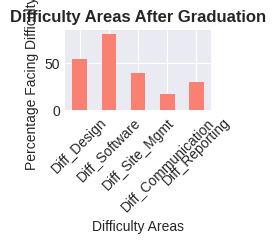

In [ ]:
# 4. Difficulty Areas
ax4 = plt.subplot(4, 3, 4)
difficulty_summary.plot(kind='bar', ax=ax4, color='salmon')
ax4.set_title('Difficulty Areas After Graduation', fontsize=12, fontweight='bold')
ax4.set_xlabel('Difficulty Areas')
ax4.set_ylabel('Percentage Facing Difficulty (%)')
ax4.tick_params(axis='x', rotation=45)

Text(0.5, 1.0, 'Correlation Between Different Ratings')

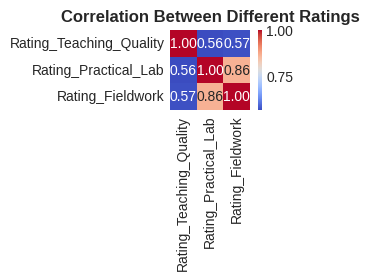

In [ ]:
# 5. Rating Distribution Heatmap
ax5 = plt.subplot(4, 3, 5)
# Use actual_rating_cols for correlation calculation
rating_corr = df_analysis[actual_rating_cols].corr()
sns.heatmap(rating_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax5, square=True)
ax5.set_title('Correlation Between Different Ratings', fontsize=12, fontweight='bold')

Text(0, 0.5, '')

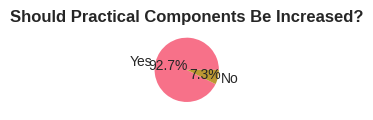

In [ ]:
# 6. Practical Components Opinion
ax6 = plt.subplot(4, 3, 6)
practical_counts.plot(kind='pie', autopct='%1.1f%%', ax=ax6)
ax6.set_title('Should Practical Components Be Increased?', fontsize=12, fontweight='bold')
ax6.set_ylabel('')

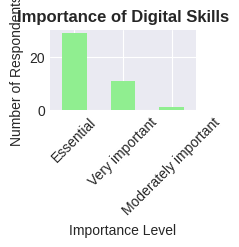

In [ ]:
# 7. Digital Skills Importance
ax7 = plt.subplot(4, 3, 7)
importance_counts.plot(kind='bar', ax=ax7, color='lightgreen')
ax7.set_title('Importance of Digital Skills', fontsize=12, fontweight='bold')
ax7.set_xlabel('Importance Level')
ax7.set_ylabel('Number of Respondents')
ax7.tick_params(axis='x', rotation=45)

Text(0, 0.5, '')

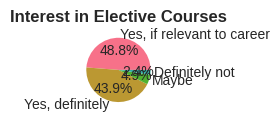

In [ ]:
# 8. Willingness to Take Elective Courses
ax9 = plt.subplot(4, 3, 9)
elective_counts.plot(kind='pie', autopct='%1.1f%%', ax=ax9)
ax9.set_title('Interest in Elective Courses', fontsize=12, fontweight='bold')
ax9.set_ylabel('')

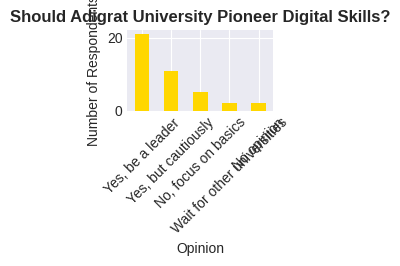

In [ ]:
# 9. Pioneer Digital Skills Opinion
ax11 = plt.subplot(4, 3, 11)
pioneer_counts.plot(kind='bar', ax=ax11, color='gold')
ax11.set_title('Should Adigrat University Pioneer Digital Skills?', fontsize=12, fontweight='bold')
ax11.set_xlabel('Opinion')
ax11.set_ylabel('Number of Respondents')
ax11.tick_params(axis='x', rotation=45)

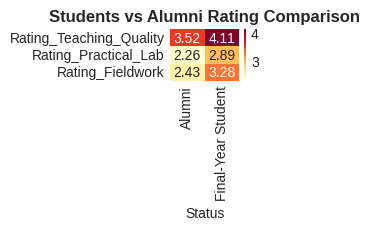

In [ ]:
# 10. Students vs Alumni Comparison Heatmap
ax12 = plt.subplot(4, 3, 12)
# Use actual_rating_cols which contains only the existing rating columns
comparison_heatmap = df_analysis.groupby('Status')[actual_rating_cols].mean().T
sns.heatmap(comparison_heatmap, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax12)
ax12.set_title('Students vs Alumni Rating Comparison', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('curriculum_analysis_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 11. KEY INSIGHTS AND RECOMMENDATIONS
print("\n" + "="*80)
print("10. KEY INSIGHTS AND RECOMMENDATIONS")
print("="*80)

# Calculate average ratings using actual_rating_cols
avg_ratings = df_analysis[actual_rating_cols].mean().sort_values()

print("\n LOWEST RATED AREAS:")
for area, rating in avg_ratings.head(3).items():
    print(f"   • {area.replace('Rating_', '')}: {rating:.2f}/5.0")

print("\n HIGHEST RATED AREAS:")
for area, rating in avg_ratings.tail(3).items():
    print(f"   • {area.replace('Rating_', '')}: {rating:.2f}/5.0")

print("\n DIGITAL SKILLS GAP ANALYSIS:")
exposure = df_analysis[['Exp_Basic_Programming', 'Exp_Data_Analysis', 'Exp_GIS', 'Exp_AI_ML']].mean() * 100
wish = df_analysis[wish_cols].sum()
for skill in wish.index:
    if skill.replace('Wish_', '') in exposure.index.str.replace('Exp_', ''):
        exp_skill = skill.replace('Wish_', 'Exp_')
        if exp_skill in exposure.index:
            print(f"   • {skill.replace('Wish_', '')}: {exposure[exp_skill]:.1f}% exposed, {wish[skill]} respondents wish they learned it")

print("\n MAIN DIFFICULTY AREAS AFTER GRADUATION:")
for area, pct in difficulty_summary.head(3).items():
    print(f"   • {area.replace('Diff_', '')}: {pct:.1f}% of respondents faced difficulty")

print("\n RECOMMENDATIONS:")
# Safely get mean for software training rating, or indicate N/A if column doesn't exist
software_training_rating_mean_str = "N/A"
if 'Rating_Software_Training' in df_analysis.columns:
    software_training_rating_mean_str = f"{df_analysis['Rating_Software_Training'].mean():.2f}/5.0"
print(f"   1. Strengthen software training (rated {software_training_rating_mean_str})")

print("   2. Increase practical/laboratory exposure (rated {:.2f}/5.0)".format(df_analysis['Rating_Practical_Lab'].mean()))
print("   3. Integrate more digital skills: {} is the most desired".format(wish_summary.index[0].replace('Wish_', '')))
print("   4. Focus on addressing difficulty in: {}".format(difficulty_summary.index[0].replace('Diff_', '')))
print("   5. {}% of respondents support pioneering digital skills integration".format(
    (pioneer_counts.get('Yes, be a leader', 0) / pioneer_counts.sum() * 100) if 'Yes, be a leader' in pioneer_counts else 0))



10. KEY INSIGHTS AND RECOMMENDATIONS

 LOWEST RATED AREAS:
   • Practical_Lab: 2.54/5.0
   • Fieldwork: 2.80/5.0
   • Teaching_Quality: 3.78/5.0

 HIGHEST RATED AREAS:
   • Practical_Lab: 2.54/5.0
   • Fieldwork: 2.80/5.0
   • Teaching_Quality: 3.78/5.0

 DIGITAL SKILLS GAP ANALYSIS:
   • Data_Analysis: 53.7% exposed, 22 respondents wish they learned it
   • GIS: 41.5% exposed, 14 respondents wish they learned it
   • AI_ML: 34.1% exposed, 8 respondents wish they learned it

 MAIN DIFFICULTY AREAS AFTER GRADUATION:
   • Design: 53.7% of respondents faced difficulty
   • Software: 80.5% of respondents faced difficulty
   • Site_Mgmt: 39.0% of respondents faced difficulty

 RECOMMENDATIONS:
   1. Strengthen software training (rated N/A)
   2. Increase practical/laboratory exposure (rated 2.54/5.0)
   3. Integrate more digital skills: Project_Mgmt is the most desired
   4. Focus on addressing difficulty in: Design
   5. 51.21951219512195% of respondents support pioneering digital skills 